# Ranking Comparativo de Modelos de Machine Learning

Este notebook gera dinamicamente um ranking de todos os modelos treinados, agrupados por:
- **Tipo de problema**: Regressão vs Classificação
- **Janela de tempo**: 3, 7, 15 e 30 dias

Os dados são carregados automaticamente a partir dos CSVs de métricas gerados no treinamento.

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

## 1. Coleta Dinâmica dos CSVs de Métricas

In [2]:
MODELS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'models')

# Mapeamento de modelos para tipo de problema
MODELOS_REGRESSAO = {'regressao_linear', 'regressao_linear_rede_neural'}
MODELOS_CLASSIFICACAO = {'regressao_logistica', 'random_forest', 'xgboost'}

# Nomes amigáveis para exibição
NOMES_MODELOS = {
    'regressao_linear': 'Regressão Linear',
    'regressao_linear_rede_neural': 'Rede Neural (Regressão)',
    'regressao_logistica': 'Regressão Logística',
    'random_forest': 'Random Forest',
    'xgboost': 'XGBoost',
}

NOMES_DATASETS = {
    'dataset_base': 'Base',
    'dataset_dummy': 'Dummy',
    'dataset_indicadores': 'Indicadores',
    'dataset_janelas': 'Janelas',
}

HORIZONTES = ['3 dias', '7 dias', '15 dias', '30 dias']

print(f'Diretório dos modelos: {MODELS_DIR}')
print(f'Existe: {os.path.exists(MODELS_DIR)}')

Diretório dos modelos: /home/gabriel/Documents/GIT/Analise-comparativa-de-modelos-de-machine-learning---Agro-Brasil---TCC/models
Existe: True


In [3]:
def coletar_metricas(models_dir):
    """
    Varre dinamicamente o diretório de modelos e coleta todos os CSVs de métricas.
    Retorna um DataFrame consolidado com colunas extras:
    - modelo, dataset, ticker, tipo (regressao/classificacao)
    """
    registros = []
    
    csv_files = glob.glob(os.path.join(models_dir, '**', '*.csv'), recursive=True)
    print(f'Total de arquivos CSV encontrados: {len(csv_files)}')
    
    for csv_path in csv_files:
        # Extrair informações do caminho
        # Estrutura: models/<modelo>/<dataset>/<subpasta>/metricas_<ticker>_<sufixo>.csv
        rel_path = os.path.relpath(csv_path, models_dir)
        parts = rel_path.split(os.sep)
        
        if len(parts) < 3:
            continue
        
        modelo = parts[0]       # ex: regressao_linear
        dataset = parts[1]      # ex: dataset_janelas
        
        # Extrair ticker do nome do arquivo
        filename = os.path.basename(csv_path)
        ticker = None
        for t in ['agro3', 'slce3', 'soja3']:
            if t in filename.lower():
                ticker = t.upper()
                break
        
        if ticker is None:
            continue
        
        # Determinar tipo
        if modelo in MODELOS_REGRESSAO:
            tipo = 'regressao'
        elif modelo in MODELOS_CLASSIFICACAO:
            tipo = 'classificacao'
        else:
            continue
        
        # Ler CSV
        try:
            df = pd.read_csv(csv_path)
            # Normalizar nome da coluna R² / R2
            df.columns = [c.replace('R²', 'R2') for c in df.columns]
            
            df['modelo'] = modelo
            df['modelo_nome'] = NOMES_MODELOS.get(modelo, modelo)
            df['dataset'] = dataset
            df['dataset_nome'] = NOMES_DATASETS.get(dataset, dataset)
            df['ticker'] = ticker
            df['tipo'] = tipo
            
            registros.append(df)
        except Exception as e:
            print(f'Erro ao ler {csv_path}: {e}')
    
    if not registros:
        print('Nenhum registro encontrado!')
        return pd.DataFrame()
    
    df_all = pd.concat(registros, ignore_index=True)
    print(f'Total de registros coletados: {len(df_all)}')
    print(f'Modelos encontrados: {sorted(df_all["modelo"].unique())}')
    print(f'Datasets encontrados: {sorted(df_all["dataset"].unique())}')
    print(f'Tickers encontrados: {sorted(df_all["ticker"].unique())}')
    print(f'Tipos: {sorted(df_all["tipo"].unique())}')
    return df_all

df_all = coletar_metricas(MODELS_DIR)
df_all.head()

Total de arquivos CSV encontrados: 60
Total de registros coletados: 240
Modelos encontrados: ['random_forest', 'regressao_linear', 'regressao_linear_rede_neural', 'regressao_logistica', 'xgboost']
Datasets encontrados: ['dataset_base', 'dataset_dummy', 'dataset_indicadores', 'dataset_janelas']
Tickers encontrados: ['AGRO3', 'SLCE3', 'SOJA3']
Tipos: ['classificacao', 'regressao']


,Horizonte,R2,MAE,RMSE,modelo,modelo_nome,dataset,dataset_nome,ticker,tipo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,3 dias,0.9392,0.3518,0.4870,regressao_linear,Regressão Linear,dataset_janelas,Janelas,SOJA3,regressao,NaN,NaN,NaN,NaN,NaN
1,7 dias,0.8873,0.4807,0.6502,regressao_linear,Regressão Linear,dataset_janelas,Janelas,SOJA3,regressao,NaN,NaN,NaN,NaN,NaN
2,15 dias,0.7533,0.7256,0.9695,regressao_linear,Regressão Linear,dataset_janelas,Janelas,SOJA3,regressao,NaN,NaN,NaN,NaN,NaN
3,30 dias,0.5431,1.1140,1.3997,regressao_linear,Regressão Linear,dataset_janelas,Janelas,SOJA3,regressao,NaN,NaN,NaN,NaN,NaN
4,3 dias,0.9892,0.4293,0.6295,regressao_linear,Regressão Linear,dataset_janelas,Janelas,AGRO3,regressao,NaN,NaN,NaN,NaN,NaN


## 2. Separação por Tipo de Problema

In [4]:
df_regressao = df_all[df_all['tipo'] == 'regressao'].copy()
df_classificacao = df_all[df_all['tipo'] == 'classificacao'].copy()

print(f'Registros de Regressão: {len(df_regressao)}')
print(f'Registros de Classificação: {len(df_classificacao)}')

Registros de Regressão: 96
Registros de Classificação: 144


---
## 3. Rankings de REGRESSÃO (por Janela de Tempo)

Métricas de regressão:
- **R²** (quanto maior, melhor)
- **MAE** (quanto menor, melhor)
- **RMSE** (quanto menor, melhor)

O ranking principal é ordenado por **R² decrescente**.

In [5]:
def ranking_regressao(df, horizonte):
    """
    Gera ranking de modelos de regressão para um horizonte específico.
    Ordenado por R² (decrescente), depois MAE (crescente).
    """
    df_h = df[df['Horizonte'] == horizonte].copy()
    if df_h.empty:
        print(f'  Sem dados para horizonte: {horizonte}')
        return pd.DataFrame()
    
    df_h = df_h.sort_values(['R2', 'MAE'], ascending=[False, True]).reset_index(drop=True)
    df_h.index = df_h.index + 1
    df_h.index.name = 'Ranking'
    
    cols = ['modelo_nome', 'dataset_nome', 'ticker', 'R2', 'MAE', 'RMSE']
    return df_h[cols].rename(columns={
        'modelo_nome': 'Modelo',
        'dataset_nome': 'Dataset',
        'ticker': 'Ticker',
    })


for horizonte in HORIZONTES:
    print(f'\n{"="*80}')
    print(f'  RANKING REGRESSÃO — {horizonte.upper()}')
    print(f'{"="*80}')
    ranking = ranking_regressao(df_regressao, horizonte)
    if not ranking.empty:
        display(ranking)


  RANKING REGRESSÃO — 3 DIAS


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Ranking,,,,,,
1,Rede Neural (Regressão),Janelas,SLCE3,0.9920,0.3571,0.4832
2,Regressão Linear,Janelas,SLCE3,0.9919,0.3580,0.4863
3,Regressão Linear,Dummy,SLCE3,0.9906,0.3680,0.5161
4,Regressão Linear,Base,SLCE3,0.9906,0.3674,0.5161
5,Rede Neural (Regressão),Base,SLCE3,0.9900,0.3827,0.5321
6,Rede Neural (Regressão),Indicadores,AGRO3,0.9899,0.4107,0.5989
7,Rede Neural (Regressão),Indicadores,SLCE3,0.9898,0.3765,0.5316
8,Rede Neural (Regressão),Dummy,SLCE3,0.9897,0.3909,0.5393
9,Regressão Linear,Indicadores,AGRO3,0.9896,0.4077,0.6075



  RANKING REGRESSÃO — 7 DIAS


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Ranking,,,,,,
1,Rede Neural (Regressão),Janelas,SLCE3,0.9816,0.5417,0.7265
2,Rede Neural (Regressão),Indicadores,SLCE3,0.9811,0.5351,0.7205
3,Regressão Linear,Janelas,SLCE3,0.9808,0.5549,0.7408
4,Rede Neural (Regressão),Dummy,SLCE3,0.9804,0.5652,0.7452
5,Rede Neural (Regressão),Base,SLCE3,0.9802,0.5638,0.7479
6,Regressão Linear,Base,SLCE3,0.9799,0.5720,0.7536
7,Regressão Linear,Dummy,SLCE3,0.9799,0.5735,0.7546
8,Rede Neural (Regressão),Indicadores,AGRO3,0.9792,0.6126,0.8545
9,Regressão Linear,Indicadores,SLCE3,0.9784,0.5614,0.7704



  RANKING REGRESSÃO — 15 DIAS


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Ranking,,,,,,
1,Rede Neural (Regressão),Indicadores,SLCE3,0.9723,0.6528,0.8682
2,Rede Neural (Regressão),Dummy,SLCE3,0.9662,0.7417,0.9715
3,Rede Neural (Regressão),Base,SLCE3,0.9658,0.7285,0.9774
4,Regressão Linear,Base,SLCE3,0.9640,0.7466,1.0022
5,Regressão Linear,Dummy,SLCE3,0.9639,0.7490,1.0046
6,Rede Neural (Regressão),Janelas,SLCE3,0.9627,0.7628,1.0118
7,Rede Neural (Regressão),Indicadores,AGRO3,0.9604,0.8273,1.1838
8,Regressão Linear,Janelas,SLCE3,0.9601,0.7840,1.0466
9,Regressão Linear,Indicadores,SLCE3,0.9595,0.7857,1.0496



  RANKING REGRESSÃO — 30 DIAS


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Ranking,,,,,,
1,Rede Neural (Regressão),Indicadores,SLCE3,0.9630,0.7561,0.9962
2,Rede Neural (Regressão),Indicadores,AGRO3,0.9448,1.0247,1.3857
3,Rede Neural (Regressão),Dummy,SLCE3,0.9406,0.9798,1.2761
4,Rede Neural (Regressão),Janelas,SLCE3,0.9327,1.0197,1.3550
5,Rede Neural (Regressão),Base,SLCE3,0.9323,1.0087,1.3625
6,Rede Neural (Regressão),Janelas,AGRO3,0.9279,1.1524,1.6038
7,Rede Neural (Regressão),Dummy,AGRO3,0.9262,1.1248,1.5944
8,Rede Neural (Regressão),Base,AGRO3,0.9238,1.1719,1.6202
9,Regressão Linear,Dummy,SLCE3,0.9173,1.1875,1.5059


---
## 4. Rankings de CLASSIFICAÇÃO (por Janela de Tempo)

Métricas de classificação:
- **Accuracy, Precision, Recall, F1-Score, AUC-ROC** (quanto maior, melhor)

O ranking principal é ordenado por **F1-Score decrescente**.

In [6]:
def ranking_classificacao(df, horizonte):
    """
    Gera ranking de modelos de classificação para um horizonte específico.
    Ordenado por F1-Score (decrescente), depois AUC-ROC (decrescente).
    """
    df_h = df[df['Horizonte'] == horizonte].copy()
    if df_h.empty:
        print(f'  Sem dados para horizonte: {horizonte}')
        return pd.DataFrame()
    
    df_h = df_h.sort_values(['F1-Score', 'AUC-ROC'], ascending=[False, False]).reset_index(drop=True)
    df_h.index = df_h.index + 1
    df_h.index.name = 'Ranking'
    
    cols = ['modelo_nome', 'dataset_nome', 'ticker', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    return df_h[cols].rename(columns={
        'modelo_nome': 'Modelo',
        'dataset_nome': 'Dataset',
        'ticker': 'Ticker',
    })


for horizonte in HORIZONTES:
    print(f'\n{"="*80}')
    print(f'  RANKING CLASSIFICAÇÃO — {horizonte.upper()}')
    print(f'{"="*80}')
    ranking = ranking_classificacao(df_classificacao, horizonte)
    if not ranking.empty:
        display(ranking)


  RANKING CLASSIFICAÇÃO — 3 DIAS


,Modelo,Dataset,Ticker,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,,
1,Random Forest,Indicadores,SOJA3,0.7529,0.7538,0.7529,0.7521,0.7986
2,XGBoost,Indicadores,SOJA3,0.6724,0.6723,0.6724,0.6718,0.7406
3,Random Forest,Indicadores,SLCE3,0.6657,0.6657,0.6657,0.6656,0.7122
4,Random Forest,Indicadores,AGRO3,0.6479,0.6482,0.6479,0.6480,0.7111
5,XGBoost,Indicadores,AGRO3,0.5947,0.5942,0.5947,0.5940,0.6316
6,XGBoost,Dummy,SOJA3,0.5955,0.5950,0.5955,0.5915,0.6008
7,XGBoost,Indicadores,SLCE3,0.5858,0.5859,0.5858,0.5858,0.6497
8,Random Forest,Dummy,SOJA3,0.5730,0.5719,0.5730,0.5713,0.5979
9,Random Forest,Janelas,SLCE3,0.5718,0.5718,0.5718,0.5711,0.6439



  RANKING CLASSIFICAÇÃO — 7 DIAS


,Modelo,Dataset,Ticker,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,,
1,Random Forest,Indicadores,SLCE3,0.7899,0.7905,0.7899,0.7900,0.8832
2,Random Forest,Indicadores,AGRO3,0.7604,0.7606,0.7604,0.7585,0.8287
3,XGBoost,Indicadores,SLCE3,0.7544,0.7550,0.7544,0.7546,0.8237
4,XGBoost,Indicadores,SOJA3,0.7299,0.7308,0.7299,0.7298,0.7989
5,XGBoost,Indicadores,AGRO3,0.7160,0.7151,0.7160,0.7143,0.7679
6,Random Forest,Indicadores,SOJA3,0.6954,0.6958,0.6954,0.6954,0.8167
7,Random Forest,Janelas,SLCE3,0.6891,0.6900,0.6891,0.6894,0.7765
8,Random Forest,Dummy,SLCE3,0.6579,0.6603,0.6579,0.6582,0.7286
9,XGBoost,Janelas,SLCE3,0.6540,0.6545,0.6540,0.6541,0.7406



  RANKING CLASSIFICAÇÃO — 15 DIAS


,Modelo,Dataset,Ticker,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,,
1,XGBoost,Indicadores,SOJA3,0.8851,0.8856,0.8851,0.8849,0.9086
2,Random Forest,Indicadores,SOJA3,0.8678,0.8697,0.8678,0.8674,0.9309
3,Random Forest,Indicadores,SLCE3,0.8491,0.8506,0.8491,0.8492,0.9219
4,XGBoost,Indicadores,AGRO3,0.8314,0.8327,0.8314,0.8298,0.8980
5,XGBoost,Indicadores,SLCE3,0.8254,0.8255,0.8254,0.8255,0.8943
6,Random Forest,Indicadores,AGRO3,0.8254,0.8257,0.8254,0.8243,0.8986
7,Random Forest,Janelas,SOJA3,0.7232,0.7231,0.7232,0.7225,0.7469
8,XGBoost,Janelas,SOJA3,0.7175,0.7180,0.7175,0.7163,0.7468
9,Random Forest,Janelas,SLCE3,0.6950,0.6945,0.6950,0.6939,0.7952



  RANKING CLASSIFICAÇÃO — 30 DIAS


,Modelo,Dataset,Ticker,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,,
1,XGBoost,Indicadores,SOJA3,0.9195,0.9200,0.9195,0.9193,0.9526
2,Random Forest,Indicadores,SOJA3,0.9023,0.9041,0.9023,0.9017,0.9548
3,Random Forest,Indicadores,SLCE3,0.8876,0.8881,0.8876,0.8877,0.9466
4,XGBoost,Indicadores,SLCE3,0.8728,0.8731,0.8728,0.8729,0.9420
5,Random Forest,Indicadores,AGRO3,0.8580,0.8588,0.8580,0.8583,0.9349
6,XGBoost,Indicadores,AGRO3,0.8550,0.8546,0.8550,0.8544,0.9144
7,Random Forest,Dummy,SOJA3,0.7978,0.7995,0.7978,0.7982,0.8781
8,XGBoost,Dummy,SOJA3,0.7528,0.7528,0.7528,0.7528,0.8667
9,Random Forest,Janelas,SOJA3,0.7458,0.7494,0.7458,0.7403,0.8537


---
## 5. Ranking Médio por Modelo (agregado por dataset e ticker)

Média das métricas de cada modelo em todos os datasets e tickers, segmentado por janela de tempo.

In [7]:
print('=' * 80)
print('  RANKING MÉDIO — REGRESSÃO (média por modelo e horizonte)')
print('=' * 80)

for horizonte in HORIZONTES:
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if df_h.empty:
        continue
    
    media = (
        df_h.groupby('modelo_nome')[['R2', 'MAE', 'RMSE']]
        .mean()
        .sort_values('R2', ascending=False)
    )
    media.index.name = 'Modelo'
    
    print(f'\n--- {horizonte} ---')
    display(media)

  RANKING MÉDIO — REGRESSÃO (média por modelo e horizonte)

--- 3 dias ---


,R2,MAE,RMSE
Modelo,,,
Regressão Linear,0.9754,0.3749,0.5234
Rede Neural (Regressão),0.9751,0.3850,0.5296



--- 7 dias ---


,R2,MAE,RMSE
Modelo,,,
Rede Neural (Regressão),0.9415,0.5640,0.7746
Regressão Linear,0.9391,0.5731,0.7892



--- 15 dias ---


,R2,MAE,RMSE
Modelo,,,
Rede Neural (Regressão),0.8975,0.7620,1.0345
Regressão Linear,0.8810,0.8055,1.0965



--- 30 dias ---


,R2,MAE,RMSE
Modelo,,,
Rede Neural (Regressão),0.8476,0.9788,1.3064
Regressão Linear,0.7887,1.1725,1.5380


In [8]:
print('=' * 80)
print('  RANKING MÉDIO — CLASSIFICAÇÃO (média por modelo e horizonte)')
print('=' * 80)

for horizonte in HORIZONTES:
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if df_h.empty:
        continue
    
    media = (
        df_h.groupby('modelo_nome')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
        .mean()
        .sort_values('F1-Score', ascending=False)
    )
    media.index.name = 'Modelo'
    
    print(f'\n--- {horizonte} ---')
    display(media)

  RANKING MÉDIO — CLASSIFICAÇÃO (média por modelo e horizonte)

--- 3 dias ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Random Forest,0.5904,0.5904,0.5904,0.5899,0.6320
XGBoost,0.5704,0.5699,0.5704,0.5687,0.6074
Regressão Logística,0.5380,0.5377,0.5380,0.5290,0.5601



--- 7 dias ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Random Forest,0.6503,0.6502,0.6503,0.6492,0.7101
XGBoost,0.6348,0.6351,0.6348,0.6298,0.6770
Regressão Logística,0.5545,0.5549,0.5545,0.5278,0.5858



--- 15 dias ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
XGBoost,0.7062,0.7056,0.7062,0.7035,0.7652
Random Forest,0.7047,0.7041,0.7047,0.7032,0.7692
Regressão Logística,0.5829,0.5800,0.5829,0.5791,0.6285



--- 30 dias ---


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Random Forest,0.7561,0.7555,0.7561,0.7542,0.8320
XGBoost,0.7437,0.7422,0.7437,0.7397,0.8209
Regressão Logística,0.6363,0.6347,0.6363,0.6334,0.6785


---
## 6. Visualizações Comparativas

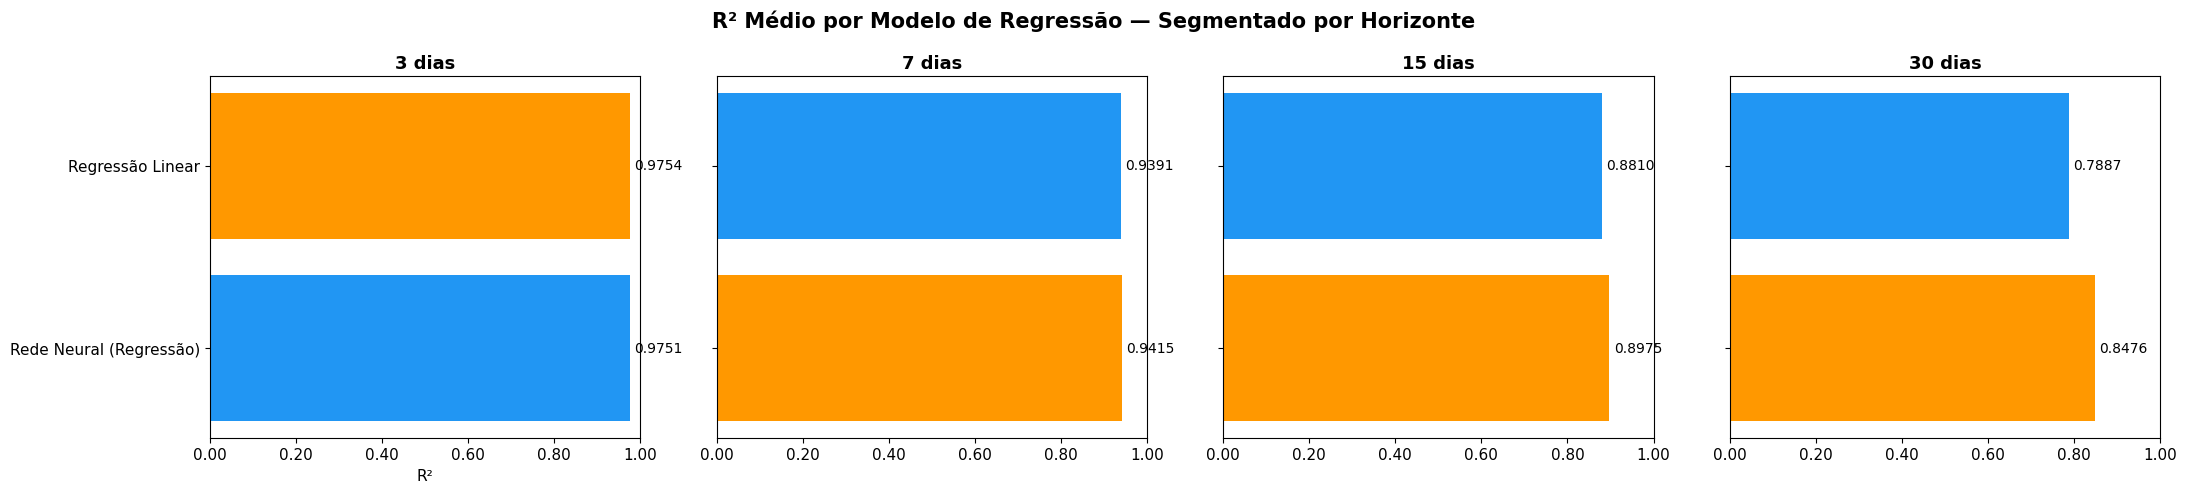

In [9]:
# ============================================================
# GRÁFICO: R² médio por modelo de regressão e horizonte
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle('R² Médio por Modelo de Regressão — Segmentado por Horizonte', fontsize=15, fontweight='bold')

cores_regressao = ['#2196F3', '#FF9800']

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue
    
    media = df_h.groupby('modelo_nome')['R2'].mean().sort_values(ascending=True)
    bars = ax.barh(media.index, media.values, color=cores_regressao[:len(media)])
    ax.set_title(horizonte, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    
    for bar, val in zip(bars, media.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
                va='center', fontsize=10)

axes[0].set_xlabel('R²')
plt.tight_layout()
plt.savefig('ranking_regressao_r2.png', bbox_inches='tight', dpi=150)
plt.show()

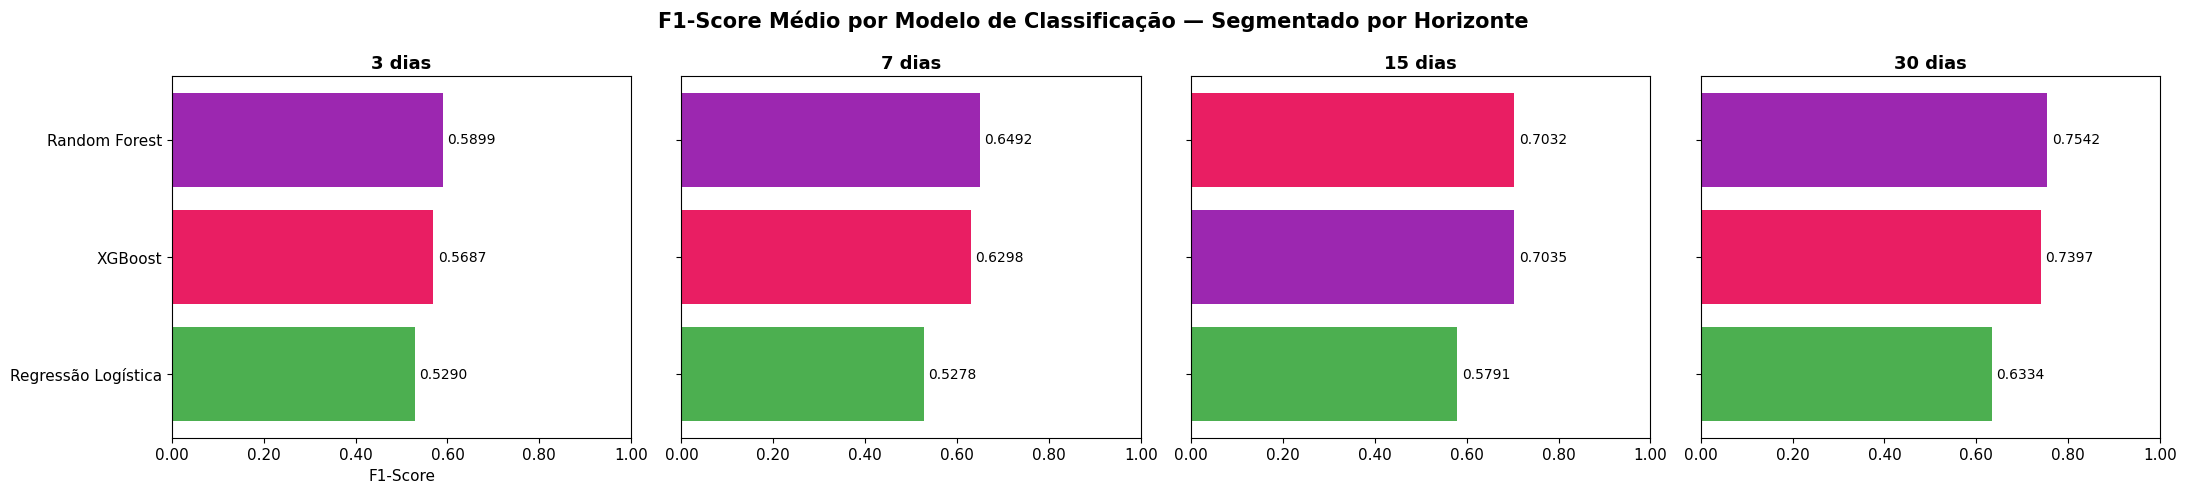

In [10]:
# ============================================================
# GRÁFICO: F1-Score médio por modelo de classificação e horizonte
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle('F1-Score Médio por Modelo de Classificação — Segmentado por Horizonte', fontsize=15, fontweight='bold')

cores_classificacao = ['#4CAF50', '#E91E63', '#9C27B0']

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i]
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if df_h.empty:
        ax.set_title(horizonte)
        continue
    
    media = df_h.groupby('modelo_nome')['F1-Score'].mean().sort_values(ascending=True)
    bars = ax.barh(media.index, media.values, color=cores_classificacao[:len(media)])
    ax.set_title(horizonte, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    
    for bar, val in zip(bars, media.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
                va='center', fontsize=10)

axes[0].set_xlabel('F1-Score')
plt.tight_layout()
plt.savefig('ranking_classificacao_f1.png', bbox_inches='tight', dpi=150)
plt.show()

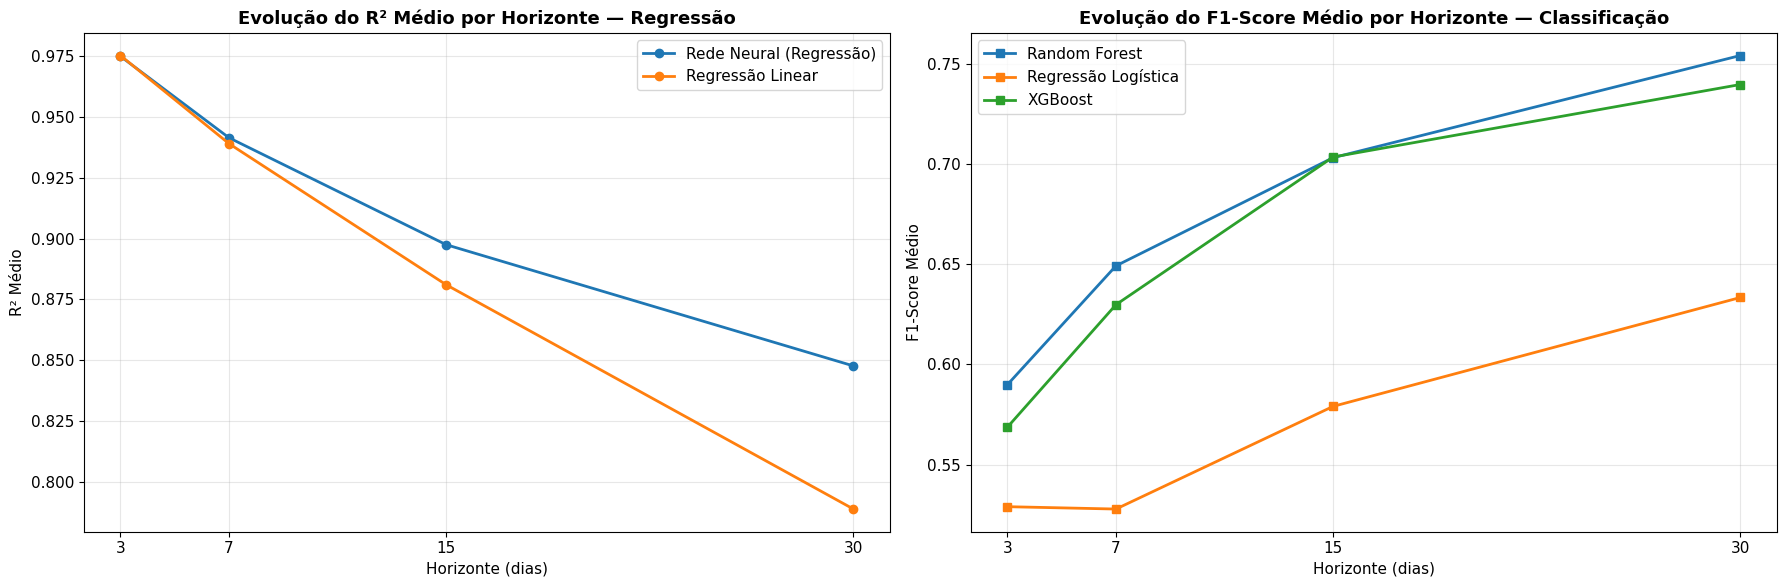

In [11]:
# ============================================================
# GRÁFICO: Evolução das métricas por horizonte (linha)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Regressão: R² por horizonte ---
ax = axes[0]
ax.set_title('Evolução do R² Médio por Horizonte — Regressão', fontsize=13, fontweight='bold')

for modelo in sorted(df_regressao['modelo_nome'].unique()):
    df_m = df_regressao[df_regressao['modelo_nome'] == modelo]
    medias = []
    for h in HORIZONTES:
        val = df_m[df_m['Horizonte'] == h]['R2'].mean()
        medias.append(val)
    ax.plot([3, 7, 15, 30], medias, marker='o', linewidth=2, label=modelo)

ax.set_xlabel('Horizonte (dias)')
ax.set_ylabel('R² Médio')
ax.set_xticks([3, 7, 15, 30])
ax.legend()
ax.grid(True, alpha=0.3)

# --- Classificação: F1-Score por horizonte ---
ax = axes[1]
ax.set_title('Evolução do F1-Score Médio por Horizonte — Classificação', fontsize=13, fontweight='bold')

for modelo in sorted(df_classificacao['modelo_nome'].unique()):
    df_m = df_classificacao[df_classificacao['modelo_nome'] == modelo]
    medias = []
    for h in HORIZONTES:
        val = df_m[df_m['Horizonte'] == h]['F1-Score'].mean()
        medias.append(val)
    ax.plot([3, 7, 15, 30], medias, marker='s', linewidth=2, label=modelo)

ax.set_xlabel('Horizonte (dias)')
ax.set_ylabel('F1-Score Médio')
ax.set_xticks([3, 7, 15, 30])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evolucao_metricas_horizonte.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Ranking por Ticker (detalhamento)

In [12]:
tickers = sorted(df_all['ticker'].unique())

print('=' * 80)
print('  RANKING POR TICKER — REGRESSÃO')
print('=' * 80)

for ticker in tickers:
    for horizonte in HORIZONTES:
        df_h = df_regressao[(df_regressao['ticker'] == ticker) & (df_regressao['Horizonte'] == horizonte)]
        if df_h.empty:
            continue
        
        df_h = df_h.sort_values('R2', ascending=False).reset_index(drop=True)
        df_h.index = df_h.index + 1
        df_h.index.name = 'Ranking'
        
        print(f'\n--- {ticker} | {horizonte} ---')
        display(df_h[['modelo_nome', 'dataset_nome', 'R2', 'MAE', 'RMSE']].rename(columns={
            'modelo_nome': 'Modelo', 'dataset_nome': 'Dataset'
        }))

  RANKING POR TICKER — REGRESSÃO

--- AGRO3 | 3 dias ---


,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Rede Neural (Regressão),Indicadores,0.9899,0.4107,0.5989
2,Regressão Linear,Indicadores,0.9896,0.4077,0.6075
3,Regressão Linear,Base,0.9892,0.4198,0.6172
4,Regressão Linear,Janelas,0.9892,0.4293,0.6295
5,Rede Neural (Regressão),Base,0.9889,0.4204,0.6249
6,Regressão Linear,Dummy,0.9887,0.4266,0.6309
7,Rede Neural (Regressão),Dummy,0.9884,0.4348,0.6388
8,Rede Neural (Regressão),Janelas,0.9879,0.4948,0.6664



--- AGRO3 | 7 dias ---


,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Rede Neural (Regressão),Indicadores,0.9792,0.6126,0.8545
2,Regressão Linear,Indicadores,0.9772,0.6087,0.8929
3,Regressão Linear,Base,0.9771,0.6106,0.9090
4,Rede Neural (Regressão),Base,0.9769,0.6113,0.9121
5,Rede Neural (Regressão),Janelas,0.9767,0.6200,0.9241
6,Regressão Linear,Janelas,0.9764,0.6223,0.9311
7,Rede Neural (Regressão),Dummy,0.9760,0.6201,0.9306
8,Regressão Linear,Dummy,0.9759,0.6222,0.9323



--- AGRO3 | 15 dias ---


...

,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Regressão Linear,Janelas,0.8873,0.4807,0.6502
2,Rede Neural (Regressão),Janelas,0.8816,0.4976,0.6663
3,Rede Neural (Regressão),Dummy,0.8659,0.5228,0.6821
4,Rede Neural (Regressão),Indicadores,0.8625,0.5181,0.6795
5,Regressão Linear,Base,0.8585,0.5556,0.7006
6,Regressão Linear,Dummy,0.8584,0.5554,0.7010
7,Rede Neural (Regressão),Base,0.8562,0.5599,0.7063
8,Regressão Linear,Indicadores,0.8394,0.5601,0.7342



--- SOJA3 | 15 dias ---


,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Rede Neural (Regressão),Indicadores,0.8133,0.6672,0.8628
2,Rede Neural (Regressão),Janelas,0.7710,0.7144,0.9341
3,Regressão Linear,Janelas,0.7533,0.7256,0.9695
4,Rede Neural (Regressão),Dummy,0.7485,0.6918,0.9013
5,Rede Neural (Regressão),Base,0.7429,0.7041,0.9112
6,Regressão Linear,Base,0.7318,0.7185,0.9307
7,Regressão Linear,Dummy,0.7314,0.7195,0.9313
8,Regressão Linear,Indicadores,0.6903,0.8523,1.1114



--- SOJA3 | 30 dias ---


,Modelo,Dataset,R2,MAE,RMSE
Ranking,,,,,
1,Rede Neural (Regressão),Indicadores,0.8464,0.6403,0.8127
2,Rede Neural (Regressão),Dummy,0.6210,0.8911,1.1752
3,Rede Neural (Regressão),Janelas,0.6207,1.0268,1.2754
4,Rede Neural (Regressão),Base,0.5918,0.9496,1.2198
5,Regressão Linear,Janelas,0.5431,1.1140,1.3997
6,Regressão Linear,Indicadores,0.5407,1.1303,1.4052
7,Regressão Linear,Dummy,0.5338,1.0000,1.3035
8,Regressão Linear,Base,0.5335,1.0026,1.3039


In [13]:
print('=' * 80)
print('  RANKING POR TICKER — CLASSIFICAÇÃO')
print('=' * 80)

for ticker in tickers:
    for horizonte in HORIZONTES:
        df_h = df_classificacao[(df_classificacao['ticker'] == ticker) & (df_classificacao['Horizonte'] == horizonte)]
        if df_h.empty:
            continue
        
        df_h = df_h.sort_values('F1-Score', ascending=False).reset_index(drop=True)
        df_h.index = df_h.index + 1
        df_h.index.name = 'Ranking'
        
        print(f'\n--- {ticker} | {horizonte} ---')
        display(df_h[['modelo_nome', 'dataset_nome', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].rename(columns={
            'modelo_nome': 'Modelo', 'dataset_nome': 'Dataset'
        }))

  RANKING POR TICKER — CLASSIFICAÇÃO

--- AGRO3 | 3 dias ---


,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,Random Forest,Indicadores,0.6479,0.6482,0.6479,0.6480,0.7111
2,XGBoost,Indicadores,0.5947,0.5942,0.5947,0.5940,0.6316
3,XGBoost,Base,0.5702,0.5694,0.5702,0.5667,0.6011
4,XGBoost,Dummy,0.5673,0.5664,0.5673,0.5640,0.6142
5,Random Forest,Dummy,0.5585,0.5584,0.5585,0.5584,0.6287
6,Random Forest,Janelas,0.5572,0.5566,0.5572,0.5566,0.6035
7,Random Forest,Base,0.5468,0.5480,0.5468,0.5468,0.6170
8,Regressão Logística,Dummy,0.5673,0.5729,0.5673,0.5460,0.5633
9,XGBoost,Janelas,0.5367,0.5352,0.5367,0.5344,0.5641



--- AGRO3 | 7 dias ---


,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,Random Forest,Indicadores,0.7604,0.7606,0.7604,0.7585,0.8287
2,XGBoost,Indicadores,0.7160,0.7151,0.7160,0.7143,0.7679
3,Random Forest,Dummy,0.6374,0.6349,0.6374,0.6330,0.6504
4,Random Forest,Base,0.6023,0.5986,0.6023,0.5975,0.6327
5,XGBoost,Dummy,0.6170,0.6201,0.6170,0.5940,0.6332
6,XGBoost,Base,0.6140,0.6161,0.6140,0.5915,0.6015
7,XGBoost,Janelas,0.5806,0.5755,0.5806,0.5732,0.5739
8,Random Forest,Janelas,0.5660,0.5629,0.5660,0.5635,0.6101
9,Regressão Logística,Dummy,0.5819,0.5857,0.5819,0.5308,0.5885



--- AGRO3 | 15 dias ---


...

,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,XGBoost,Indicadores,0.7299,0.7308,0.7299,0.7298,0.7989
2,Random Forest,Indicadores,0.6954,0.6958,0.6954,0.6954,0.8167
3,Random Forest,Dummy,0.6124,0.6124,0.6124,0.6124,0.6574
4,Random Forest,Janelas,0.5989,0.5990,0.5989,0.5989,0.6368
5,XGBoost,Dummy,0.5899,0.5907,0.5899,0.5880,0.6313
6,Regressão Logística,Indicadores,0.5747,0.5763,0.5747,0.5736,0.6537
7,XGBoost,Janelas,0.5537,0.5540,0.5537,0.5537,0.5769
8,Random Forest,Base,0.5506,0.5505,0.5506,0.5504,0.5861
9,Regressão Logística,Dummy,0.5506,0.5552,0.5506,0.5442,0.6091



--- SOJA3 | 15 dias ---


,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,XGBoost,Indicadores,0.8851,0.8856,0.8851,0.8849,0.9086
2,Random Forest,Indicadores,0.8678,0.8697,0.8678,0.8674,0.9309
3,Random Forest,Janelas,0.7232,0.7231,0.7232,0.7225,0.7469
4,XGBoost,Janelas,0.7175,0.7180,0.7175,0.7163,0.7468
5,XGBoost,Dummy,0.6573,0.6585,0.6573,0.6543,0.7132
6,Random Forest,Dummy,0.6404,0.6400,0.6404,0.6395,0.7205
7,Regressão Logística,Dummy,0.6348,0.6350,0.6348,0.6349,0.6843
8,Regressão Logística,Base,0.6236,0.6238,0.6236,0.6237,0.6834
9,XGBoost,Base,0.6124,0.6126,0.6124,0.6081,0.6603



--- SOJA3 | 30 dias ---


,Modelo,Dataset,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Ranking,,,,,,,
1,XGBoost,Indicadores,0.9195,0.9200,0.9195,0.9193,0.9526
2,Random Forest,Indicadores,0.9023,0.9041,0.9023,0.9017,0.9548
3,Random Forest,Dummy,0.7978,0.7995,0.7978,0.7982,0.8781
4,XGBoost,Dummy,0.7528,0.7528,0.7528,0.7528,0.8667
5,Random Forest,Janelas,0.7458,0.7494,0.7458,0.7403,0.8537
6,XGBoost,Janelas,0.7345,0.7349,0.7345,0.7306,0.8179
7,Regressão Logística,Indicadores,0.7011,0.7011,0.7011,0.7011,0.7412
8,Random Forest,Base,0.6910,0.6906,0.6910,0.6908,0.7560
9,Regressão Logística,Base,0.6854,0.6835,0.6854,0.6837,0.7137


---
## 8. Heatmaps: Desempenho por Modelo × Dataset

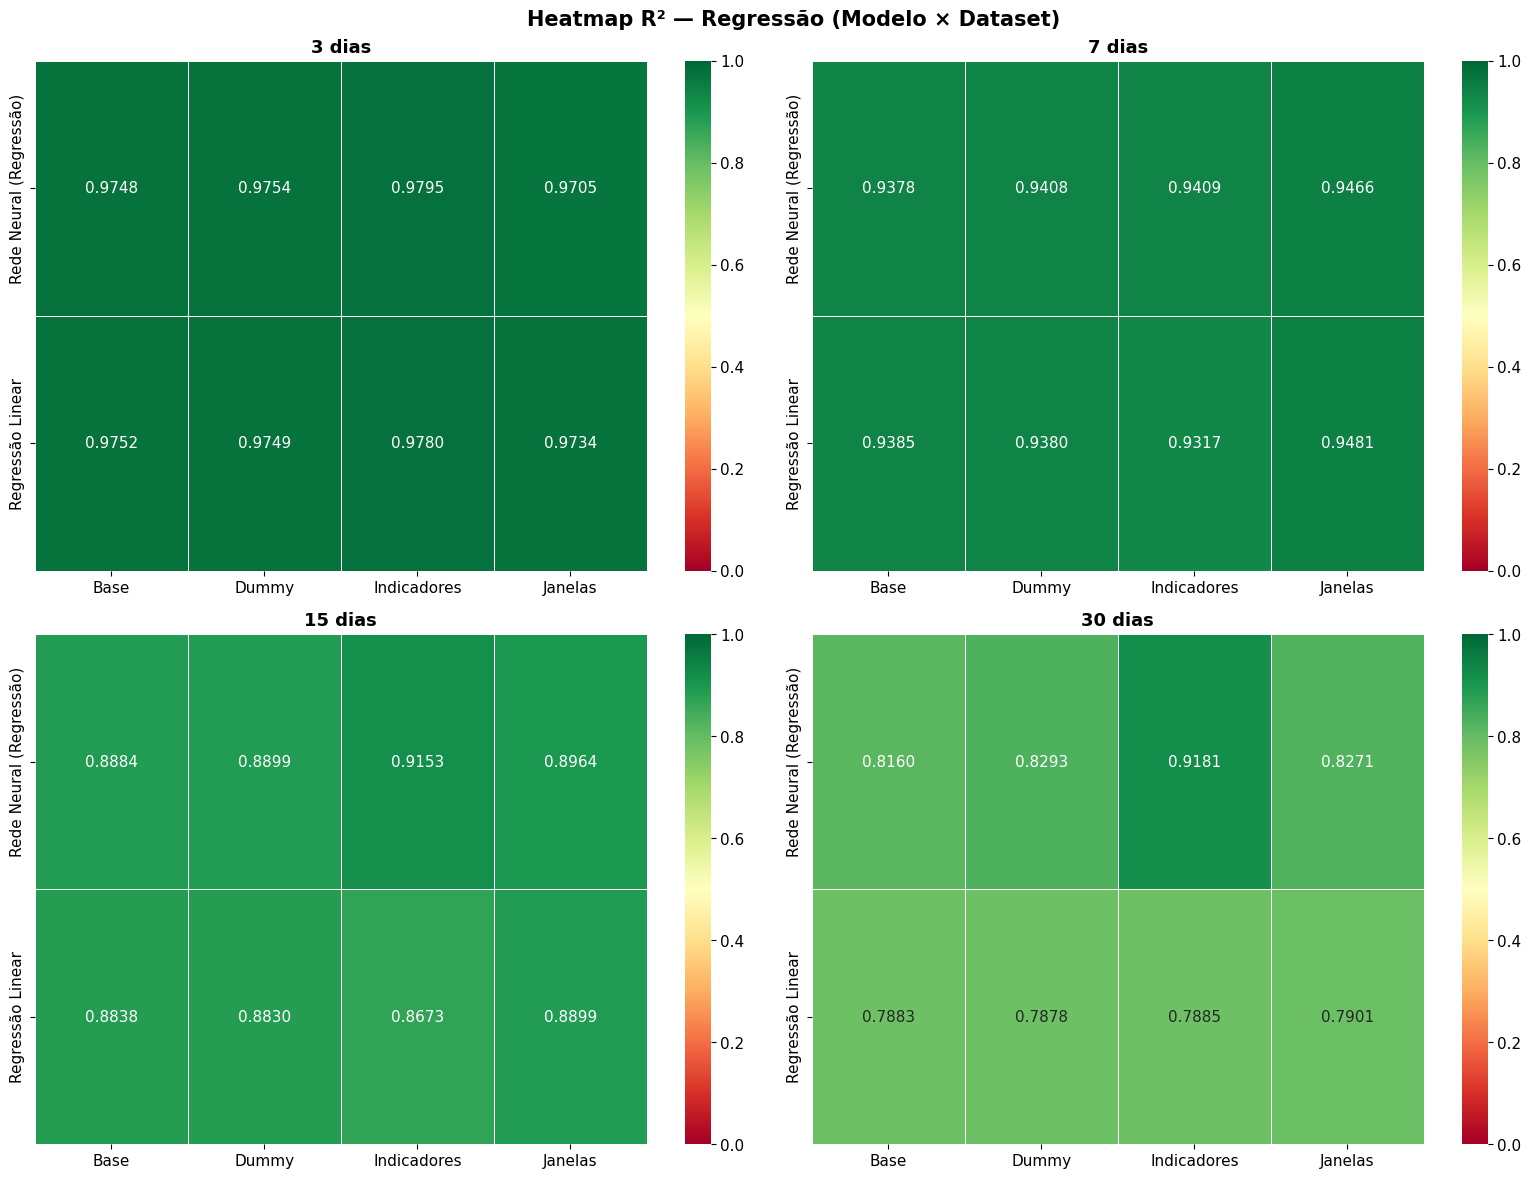

In [14]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Heatmap R² — Regressão (Modelo × Dataset)', fontsize=15, fontweight='bold')

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i // 2][i % 2]
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    
    if df_h.empty:
        ax.set_title(f'{horizonte} (sem dados)')
        continue
    
    pivot = df_h.pivot_table(
        values='R2', index='modelo_nome', columns='dataset_nome', aggfunc='mean'
    )
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
                vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f'{horizonte}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_regressao_r2.png', bbox_inches='tight', dpi=150)
plt.show()

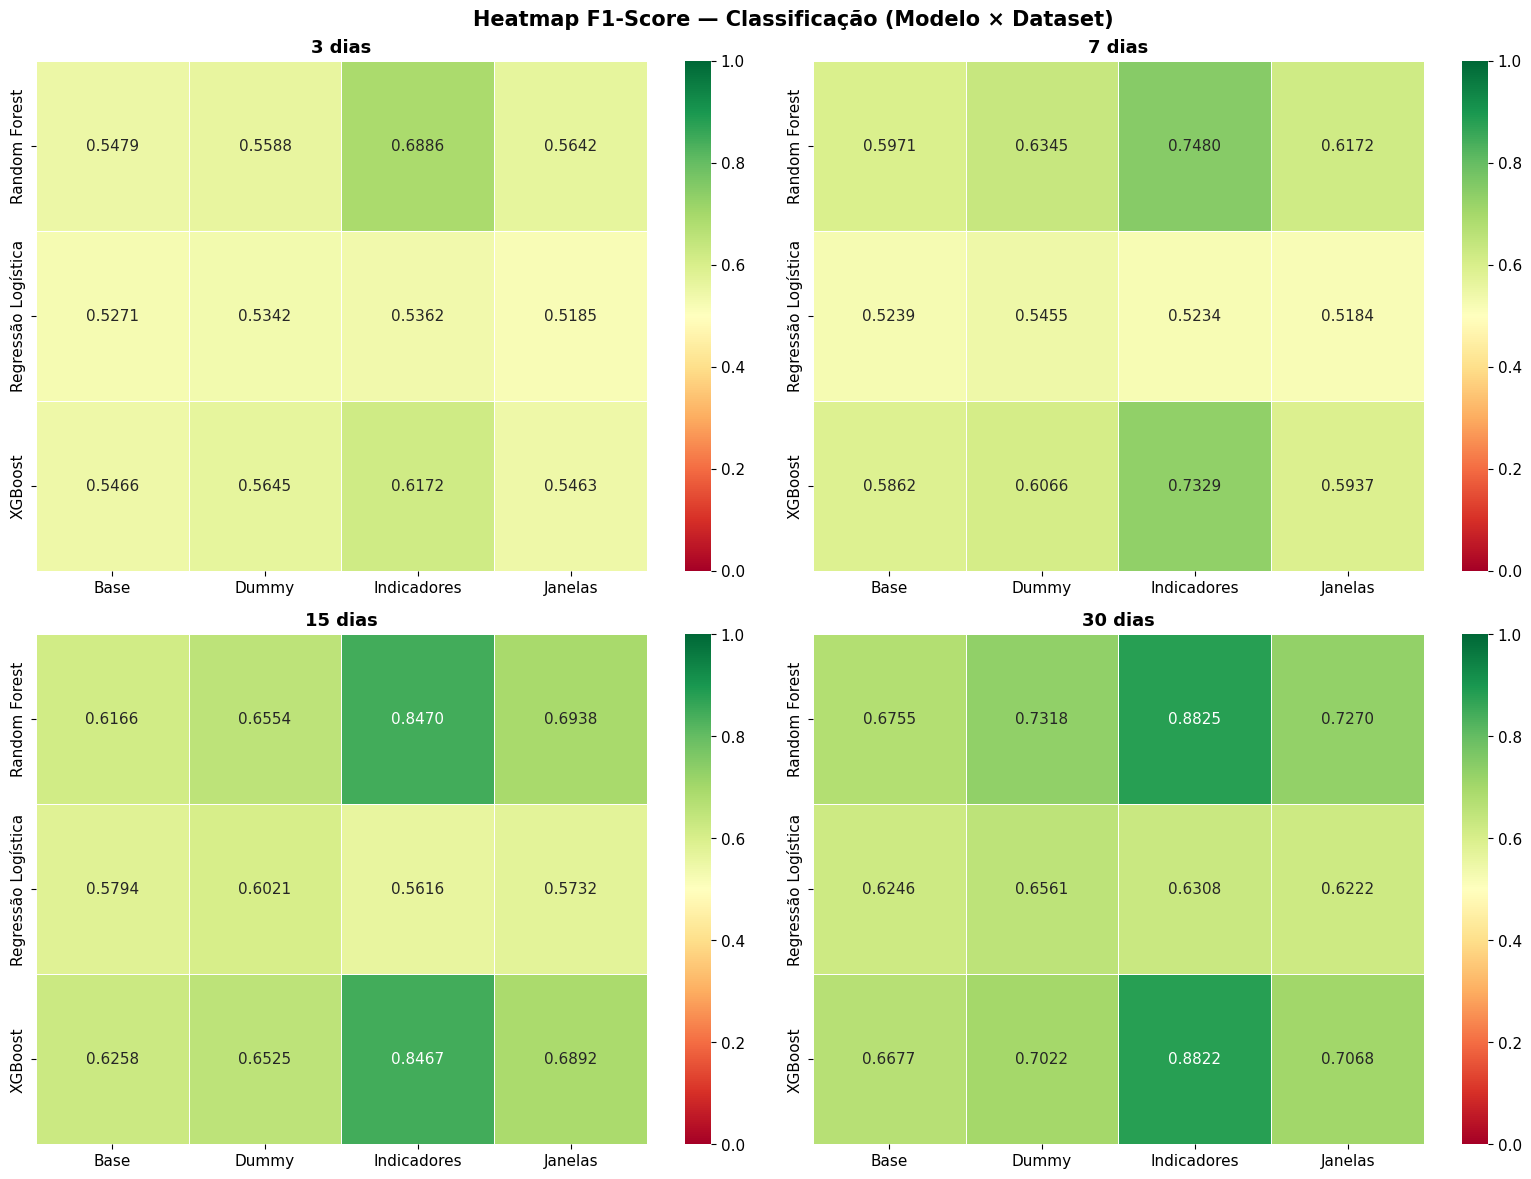

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Heatmap F1-Score — Classificação (Modelo × Dataset)', fontsize=15, fontweight='bold')

for i, horizonte in enumerate(HORIZONTES):
    ax = axes[i // 2][i % 2]
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    
    if df_h.empty:
        ax.set_title(f'{horizonte} (sem dados)')
        continue
    
    pivot = df_h.pivot_table(
        values='F1-Score', index='modelo_nome', columns='dataset_nome', aggfunc='mean'
    )
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax,
                vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f'{horizonte}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_classificacao_f1.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. Resumo Final: Melhor Modelo por Horizonte

In [16]:
print('=' * 80)
print('  MELHOR MODELO POR HORIZONTE')
print('=' * 80)

resumo_regressao = []
resumo_classificacao = []

for horizonte in HORIZONTES:
    # Regressão: melhor R²
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if not df_h.empty:
        best = df_h.loc[df_h['R2'].idxmax()]
        resumo_regressao.append({
            'Horizonte': horizonte,
            'Modelo': best['modelo_nome'],
            'Dataset': best['dataset_nome'],
            'Ticker': best['ticker'],
            'R2': best['R2'],
            'MAE': best['MAE'],
            'RMSE': best['RMSE'],
        })
    
    # Classificação: melhor F1-Score
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if not df_h.empty:
        best = df_h.loc[df_h['F1-Score'].idxmax()]
        resumo_classificacao.append({
            'Horizonte': horizonte,
            'Modelo': best['modelo_nome'],
            'Dataset': best['dataset_nome'],
            'Ticker': best['ticker'],
            'Accuracy': best['Accuracy'],
            'F1-Score': best['F1-Score'],
            'AUC-ROC': best['AUC-ROC'],
        })

print('\n--- Regressão (melhor R²) ---')
display(pd.DataFrame(resumo_regressao).set_index('Horizonte'))

print('\n--- Classificação (melhor F1-Score) ---')
display(pd.DataFrame(resumo_classificacao).set_index('Horizonte'))

  MELHOR MODELO POR HORIZONTE

--- Regressão (melhor R²) ---


,Modelo,Dataset,Ticker,R2,MAE,RMSE
Horizonte,,,,,,
3 dias,Rede Neural (Regressão),Janelas,SLCE3,0.9920,0.3571,0.4832
7 dias,Rede Neural (Regressão),Janelas,SLCE3,0.9816,0.5417,0.7265
15 dias,Rede Neural (Regressão),Indicadores,SLCE3,0.9723,0.6528,0.8682
30 dias,Rede Neural (Regressão),Indicadores,SLCE3,0.9630,0.7561,0.9962



--- Classificação (melhor F1-Score) ---


,Modelo,Dataset,Ticker,Accuracy,F1-Score,AUC-ROC
Horizonte,,,,,,
3 dias,Random Forest,Indicadores,SOJA3,0.7529,0.7521,0.7986
7 dias,Random Forest,Indicadores,SLCE3,0.7899,0.7900,0.8832
15 dias,XGBoost,Indicadores,SOJA3,0.8851,0.8849,0.9086
30 dias,XGBoost,Indicadores,SOJA3,0.9195,0.9193,0.9526


---
## 10. Exportar Rankings Consolidados

In [17]:
# Exportar CSVs consolidados para análise posterior
output_dir = os.path.dirname(os.path.abspath('__file__'))

df_regressao.to_csv(os.path.join(output_dir, 'consolidado_regressao.csv'), index=False)
df_classificacao.to_csv(os.path.join(output_dir, 'consolidado_classificacao.csv'), index=False)

# Rankings médios por modelo e horizonte
ranking_medio_reg = []
ranking_medio_clf = []

for horizonte in HORIZONTES:
    # Regressão
    df_h = df_regressao[df_regressao['Horizonte'] == horizonte]
    if not df_h.empty:
        media = df_h.groupby('modelo_nome')[['R2', 'MAE', 'RMSE']].mean().reset_index()
        media['Horizonte'] = horizonte
        ranking_medio_reg.append(media)
    
    # Classificação
    df_h = df_classificacao[df_classificacao['Horizonte'] == horizonte]
    if not df_h.empty:
        media = df_h.groupby('modelo_nome')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].mean().reset_index()
        media['Horizonte'] = horizonte
        ranking_medio_clf.append(media)

if ranking_medio_reg:
    pd.concat(ranking_medio_reg).to_csv(os.path.join(output_dir, 'ranking_medio_regressao.csv'), index=False)

if ranking_medio_clf:
    pd.concat(ranking_medio_clf).to_csv(os.path.join(output_dir, 'ranking_medio_classificacao.csv'), index=False)

print('Arquivos exportados com sucesso:')
print('  - consolidado_regressao.csv')
print('  - consolidado_classificacao.csv')
print('  - ranking_medio_regressao.csv')
print('  - ranking_medio_classificacao.csv')

Arquivos exportados com sucesso:
  - consolidado_regressao.csv
  - consolidado_classificacao.csv
  - ranking_medio_regressao.csv
  - ranking_medio_classificacao.csv
